<h1 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #1f2937 45%, #334155 100%);
  padding: 16px 20px;
  border-radius: 14px;
  text-align: center;
  box-shadow: 0 12px 30px rgba(0,0,0,.35);
  font-family: Arial, sans-serif;
  margin: 0;
">
Boosting - Diabetes
</h1>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Carga de librerias y de los datos procesados
</h2>

In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from IPython.display import display
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report)

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Carga de datos guardados del proyecto anterior
</h2>

In [2]:
BASE_PATH = "../data/processed/diabetes_decision_tree/"

df = pd.read_csv(f"{BASE_PATH}diabetes_ready.csv")
X_train = pd.read_csv(f"{BASE_PATH}X_train.csv")
X_test = pd.read_csv(f"{BASE_PATH}X_test.csv")
y_train = pd.read_csv(f"{BASE_PATH}y_train.csv").squeeze("columns")
y_test = pd.read_csv(f"{BASE_PATH}y_test.csv").squeeze("columns")

print("Shape de df:", df.shape)
print("Shape de X_train:", X_train.shape)
print("Shape de X_test:", X_test.shape)
print("Shape de y_train:", y_train.shape)
print("Shape de y_test:", y_test.shape)

display(X_train.head())

Shape de df: (768, 9)
Shape de X_train: (614, 8)
Shape de X_test: (154, 8)
Shape de y_train: (614,)
Shape de y_test: (154,)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,1,90.0,62.0,12.0,43.0,27.2,0.580,24
1,5,126.0,78.0,27.0,22.0,29.6,0.439,40
2,2,105.0,58.0,40.0,94.0,34.9,0.225,25
3,1,146.0,56.0,29.0,125.0,29.7,0.564,29
4,0,95.0,64.0,39.0,105.0,44.6,0.366,22


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Entrenamiento del modelo base de Boosting
</h2>

In [3]:
gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

y_train_pred_gb = gb_model.predict(X_train)
y_test_pred_gb = gb_model.predict(X_test)

gb_metrics = pd.DataFrame({
    "dataset": ["train", "test"],
    "accuracy": [
        accuracy_score(y_train, y_train_pred_gb),
        accuracy_score(y_test, y_test_pred_gb)
    ],
    "precision": [
        precision_score(y_train, y_train_pred_gb),
        precision_score(y_test, y_test_pred_gb)
    ],
    "recall": [
        recall_score(y_train, y_train_pred_gb),
        recall_score(y_test, y_test_pred_gb)
    ],
    "f1_score": [
        f1_score(y_train, y_train_pred_gb),
        f1_score(y_test, y_test_pred_gb)
    ]
})

display(gb_metrics)

print("Matriz de confusion en test:")
display(pd.DataFrame(confusion_matrix(y_test, y_test_pred_gb)))

print("Classification report en test:")
print(classification_report(y_test, y_test_pred_gb))

,dataset,accuracy,precision,recall,f1_score
0,train,0.925081,0.932990,0.845794,0.887255
1,test,0.759740,0.688889,0.574074,0.626263


Matriz de confusion en test:


,0,1
0,86,14
1,23,31


Classification report en test:
              precision    recall  f1-score   support

           0       0.79      0.86      0.82       100
           1       0.69      0.57      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.72       154
weighted avg       0.75      0.76      0.75       154



<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Aqui veo que el modelo de <span style="color:#D11A2A; font-weight:700;">Gradient Boosting</span> aprende muy bien en <span style="color:#D11A2A; font-weight:700;">train</span>, donde alcanza un <span style="color:#D11A2A; font-weight:700;">accuracy de 0.9251</span>. Pero en <span style="color:#D11A2A; font-weight:700;">test</span> baja a <span style="color:#D11A2A; font-weight:700;">0.7597</span>, lo que me dice que hay una diferencia clara entre entrenamiento y prueba.
  </p>
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    La clase <span style="color:#D11A2A; font-weight:700;">0</span> queda mejor predicha, con <span style="color:#D11A2A; font-weight:700;">precision 0.79</span>, <span style="color:#D11A2A; font-weight:700;">recall 0.86</span> y <span style="color:#D11A2A; font-weight:700;">f1-score 0.82</span>. En cambio, la clase <span style="color:#D11A2A; font-weight:700;">1</span>, que es la mas importante en este problema, queda mas debil, con <span style="color:#D11A2A; font-weight:700;">recall 0.57</span> y <span style="color:#D11A2A; font-weight:700;">f1-score 0.63</span>.
  </p>
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    La matriz de confusion confirma esto: el modelo acierta bien los casos de la clase <span style="color:#D11A2A; font-weight:700;">0</span> con <span style="color:#D11A2A; font-weight:700;">86 aciertos</span>, pero todavia deja escapar <span style="color:#D11A2A; font-weight:700;">23 casos reales de la clase 1</span>. En resumen, este boosting funciona, pero por ahora no parece una mejora fuerte, asi que el siguiente paso sera ajustar hiperparametros para ver si podemos subir el rendimiento en <span style="color:#D11A2A; font-weight:700;">test</span>, sobre todo en la deteccion de la clase positiva.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Ajuste de hiperparametros del modelo de Boosting
</h2>

In [4]:
boosting_configs = [
    {"n_estimators": 50, "learning_rate": 0.05, "max_depth": 1},
    {"n_estimators": 100, "learning_rate": 0.05, "max_depth": 1},
    {"n_estimators": 200, "learning_rate": 0.05, "max_depth": 1},
    {"n_estimators": 50, "learning_rate": 0.1, "max_depth": 1},
    {"n_estimators": 100, "learning_rate": 0.1, "max_depth": 1},
    {"n_estimators": 200, "learning_rate": 0.1, "max_depth": 1},
    {"n_estimators": 50, "learning_rate": 0.05, "max_depth": 2},
    {"n_estimators": 100, "learning_rate": 0.05, "max_depth": 2},
    {"n_estimators": 200, "learning_rate": 0.05, "max_depth": 2},
    {"n_estimators": 50, "learning_rate": 0.1, "max_depth": 2},
    {"n_estimators": 100, "learning_rate": 0.1, "max_depth": 2},
    {"n_estimators": 200, "learning_rate": 0.1, "max_depth": 2},
]

boosting_results = []

for config in boosting_configs:
    model = GradientBoostingClassifier(
        n_estimators=config["n_estimators"],
        learning_rate=config["learning_rate"],
        max_depth=config["max_depth"],
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    boosting_results.append({
        "n_estimators": config["n_estimators"],
        "learning_rate": config["learning_rate"],
        "max_depth": config["max_depth"],
        "accuracy_train": accuracy_score(y_train, y_train_pred),
        "accuracy_test": accuracy_score(y_test, y_test_pred)
    })

boosting_results = pd.DataFrame(boosting_results).sort_values(
    by="accuracy_test", ascending=False
).reset_index(drop=True)

display(boosting_results)

,n_estimators,learning_rate,max_depth,accuracy_train,accuracy_test
0,200,0.10,2,0.902280,0.766234
1,200,0.10,1,0.811075,0.759740
2,200,0.05,1,0.801303,0.753247
3,100,0.10,1,0.806189,0.753247
4,100,0.10,2,0.858306,0.740260
5,200,0.05,2,0.855049,0.740260
6,50,0.10,1,0.794788,0.740260
7,100,0.05,1,0.794788,0.733766
8,50,0.10,2,0.835505,0.733766
9,100,0.05,2,0.830619,0.720779


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Aqui veo que la mejor configuracion fue <span style="color:#D11A2A; font-weight:700;">n_estimators = 200</span>, <span style="color:#D11A2A; font-weight:700;">learning_rate = 0.10</span> y <span style="color:#D11A2A; font-weight:700;">max_depth = 2</span>, con un <span style="color:#D11A2A; font-weight:700;">accuracy_test de 0.7662</span>. Esta fue la combinacion que mejor rindio entre todas las que probe.
  </p>
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Tambien noto que cuando aumento la cantidad de arboles y mantengo un <span style="color:#D11A2A; font-weight:700;">learning_rate</span> mas alto, el modelo suele mejorar en test. En cambio, las configuraciones mas pequenas, como <span style="color:#D11A2A; font-weight:700;">50 estimators</span> con <span style="color:#D11A2A; font-weight:700;">0.05</span>, quedaron bastante mas flojas.
  </p>
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Aun asi, la diferencia entre <span style="color:#D11A2A; font-weight:700;">accuracy_train</span> y <span style="color:#D11A2A; font-weight:700;">accuracy_test</span> sigue existiendo, aunque aqui se ve un comportamiento mas equilibrado que en otros intentos. En resumen, ya encontre una configuracion candidata para quedarme con el mejor modelo de <span style="color:#D11A2A; font-weight:700;">boosting</span>.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Grafico 📈 del rendimiento de las configuraciones probadas
</h2>

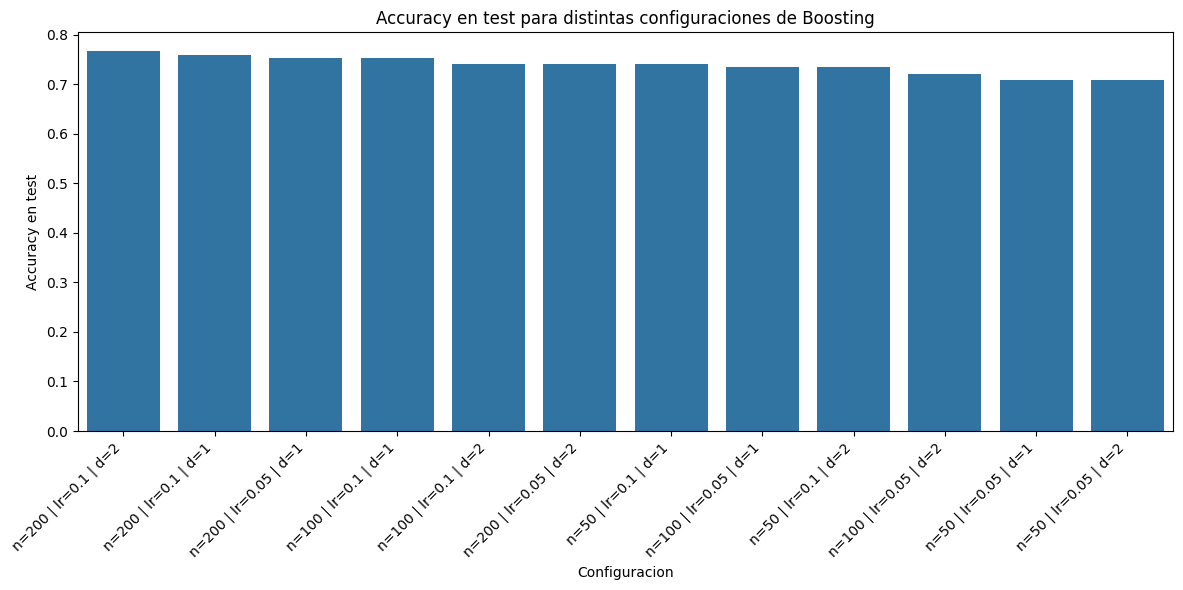

In [5]:
boosting_results_plot = boosting_results.copy()
boosting_results_plot["config"] = (
    "n=" + boosting_results_plot["n_estimators"].astype(str) +
    " | lr=" + boosting_results_plot["learning_rate"].astype(str) +
    " | d=" + boosting_results_plot["max_depth"].astype(str)
)

plt.figure(figsize=(12, 6))
sns.barplot(data=boosting_results_plot, x="config", y="accuracy_test")
plt.title("Accuracy en test para distintas configuraciones de Boosting")
plt.xlabel("Configuracion")
plt.ylabel("Accuracy en test")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    En el grafico veo de forma mas clara que la mejor configuracion fue <span style="color:#D11A2A; font-weight:700;">n=200</span>, <span style="color:#D11A2A; font-weight:700;">lr=0.1</span> y <span style="color:#D11A2A; font-weight:700;">d=2</span>, porque alcanza la barra mas alta en <span style="color:#D11A2A; font-weight:700;">accuracy_test</span>.
  </p>
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Tambien noto que las configuraciones con <span style="color:#D11A2A; font-weight:700;">200 estimators</span> se comportan mejor en general. Eso me dice que darle mas iteraciones al boosting si ayuda a corregir errores y mejorar la prediccion.
  </p>
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Aun asi, las diferencias entre varias barras no son enormes. Esto significa que hubo mejora, pero no una distancia tan grande como para decir que cualquier cambio pequeno transforma por completo el modelo. Por eso, ya tiene sentido quedarme con la mejor combinacion encontrada y evaluarla con mas detalle.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Entrenamiento del mejor modelo de Boosting y guardado
</h2>


In [6]:
best_gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=2,
    random_state=42
)

best_gb_model.fit(X_train, y_train)

y_train_pred_best_gb = best_gb_model.predict(X_train)
y_test_pred_best_gb = best_gb_model.predict(X_test)

best_gb_metrics = pd.DataFrame({
    "dataset": ["train", "test"],
    "accuracy": [
        accuracy_score(y_train, y_train_pred_best_gb),
        accuracy_score(y_test, y_test_pred_best_gb)
    ],
    "precision": [
        precision_score(y_train, y_train_pred_best_gb),
        precision_score(y_test, y_test_pred_best_gb)
    ],
    "recall": [
        recall_score(y_train, y_train_pred_best_gb),
        recall_score(y_test, y_test_pred_best_gb)
    ],
    "f1_score": [
        f1_score(y_train, y_train_pred_best_gb),
        f1_score(y_test, y_test_pred_best_gb)
    ]
})

display(best_gb_metrics)

print("Matriz de confusion del mejor modelo en test:")
display(pd.DataFrame(confusion_matrix(y_test, y_test_pred_best_gb)))

print("Classification report del mejor modelo en test:")
print(classification_report(y_test, y_test_pred_best_gb))

joblib.dump(best_gb_model, "../models/gradient_boosting_diabetes.pkl")
print("Modelo guardado en ../models/gradient_boosting_diabetes.pkl")

,dataset,accuracy,precision,recall,f1_score
0,train,0.902280,0.918478,0.78972,0.849246
1,test,0.766234,0.680000,0.62963,0.653846


Matriz de confusion del mejor modelo en test:


,0,1
0,84,16
1,20,34


Classification report del mejor modelo en test:
              precision    recall  f1-score   support

           0       0.81      0.84      0.82       100
           1       0.68      0.63      0.65        54

    accuracy                           0.77       154
   macro avg       0.74      0.73      0.74       154
weighted avg       0.76      0.77      0.76       154

Modelo guardado en ../models/gradient_boosting_diabetes.pkl


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Aqui confirmo que la mejor configuracion de <span style="color:#D11A2A; font-weight:700;">boosting</span> fue <span style="color:#D11A2A; font-weight:700;">n_estimators=200</span>, <span style="color:#D11A2A; font-weight:700;">learning_rate=0.1</span> y <span style="color:#D11A2A; font-weight:700;">max_depth=2</span>. Con esta combinacion el modelo alcanzo un <span style="color:#D11A2A; font-weight:700;">accuracy_train de 0.9023</span> y un <span style="color:#D11A2A; font-weight:700;">accuracy_test de 0.7662</span>.
  </p>
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Esto significa que el modelo mejoro frente al <span style="color:#D11A2A; font-weight:700;">boosting base</span>, que tenia un <span style="color:#D11A2A; font-weight:700;">accuracy_test de 0.7597</span>. La mejora existe, pero es pequena, de apenas <span style="color:#D11A2A; font-weight:700;">0.0065 puntos</span>.
  </p>
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Tambien veo que sigue habiendo una diferencia entre <span style="color:#D11A2A; font-weight:700;">train</span> y <span style="color:#D11A2A; font-weight:700;">test</span>, asi que el modelo sigue ajustandose mejor a entrenamiento que a prueba. En resumen, este queda como el <span style="color:#D11A2A; font-weight:700;">mejor boosting del proyecto</span>, pero no representa una mejora grande por si solo.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Comparacion final de los modelos
</h2>


In [7]:
model_comparison = pd.DataFrame({
    "modelo": ["Decision Tree", "Random Forest", "Gradient Boosting"],
    "accuracy_test": [0.792208, 0.779221, 0.766234]
})

display(model_comparison.sort_values(by="accuracy_test", ascending=False).reset_index(drop=True))

,modelo,accuracy_test
0,Decision Tree,0.792208
1,Random Forest,0.779221
2,Gradient Boosting,0.766234


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Aqui comparo el rendimiento final de los tres modelos. El mejor <span style="color:#D11A2A; font-weight:700;">accuracy_test</span> lo obtuvo <span style="color:#D11A2A; font-weight:700;">Decision Tree</span> con <span style="color:#D11A2A; font-weight:700;">0.7922</span>.
  </p>
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    En segundo lugar quedo <span style="color:#D11A2A; font-weight:700;">Random Forest</span> con <span style="color:#D11A2A; font-weight:700;">0.7792</span>, y en tercer lugar <span style="color:#D11A2A; font-weight:700;">Gradient Boosting</span> con <span style="color:#D11A2A; font-weight:700;">0.7662</span>.
  </p>
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Esto me dice que, en este problema y con las pruebas realizadas, <span style="color:#D11A2A; font-weight:700;">boosting no logro superar</span> a los modelos anteriores. Por tanto, si tengo que quedarme con uno solo por rendimiento final, me quedo con <span style="color:#D11A2A; font-weight:700;">Decision Tree</span>.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Grafico 📈 comparativo de accuracy
</h2>

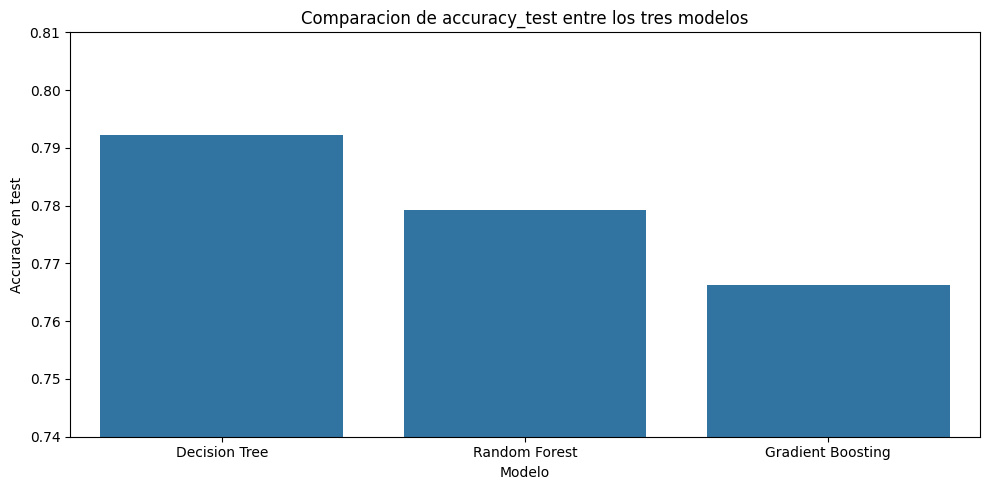

In [8]:
comparison_plot = model_comparison.sort_values(by="accuracy_test", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_plot, x="modelo", y="accuracy_test")
plt.title("Comparacion de accuracy_test entre los tres modelos")
plt.xlabel("Modelo")
plt.ylabel("Accuracy en test")
plt.ylim(0.74, 0.81)
plt.tight_layout()
plt.show()

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    El grafico confirma visualmente que el modelo con mejor resultado fue <span style="color:#D11A2A; font-weight:700;">Decision Tree</span>. La diferencia no es enorme, pero si suficiente para quedar por encima de <span style="color:#D11A2A; font-weight:700;">Random Forest</span> y <span style="color:#D11A2A; font-weight:700;">Boosting</span>.
  </p>
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    En este proyecto, probar un modelo mas complejo no significo automaticamente obtener mejores resultados. Aqui el modelo mas simple ajustado correctamente fue el que mejor respondio en los datos de prueba.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Conclusion final
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    En este proyecto entrene y ajuste un modelo de <span style="color:#D11A2A; font-weight:700;">Gradient Boosting</span> para intentar mejorar la prediccion de diabetes. La mejor configuracion encontrada fue <span style="color:#D11A2A; font-weight:700;">n_estimators=200</span>, <span style="color:#D11A2A; font-weight:700;">learning_rate=0.1</span> y <span style="color:#D11A2A; font-weight:700;">max_depth=2</span>, con un <span style="color:#D11A2A; font-weight:700;">accuracy_test de 0.7662</span>.
  </p>
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Aunque hubo una pequena mejora frente al boosting base, este modelo no logro superar a los dos modelos anteriores. El mejor resultado general siguio siendo <span style="color:#D11A2A; font-weight:700;">Decision Tree</span> con <span style="color:#D11A2A; font-weight:700;">0.7922</span>, seguido de <span style="color:#D11A2A; font-weight:700;">Random Forest</span> con <span style="color:#D11A2A; font-weight:700;">0.7792</span>.
  </p>
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Tambien vi que <span style="color:#D11A2A; font-weight:700;">Boosting</span> predijo mejor la clase <span style="color:#D11A2A; font-weight:700;">0</span> que la clase <span style="color:#D11A2A; font-weight:700;">1</span>. Esto es importante porque la clase positiva es la que mas interesa detectar en este problema, y justamente ahi el modelo quedo mas debil.
  </p>
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    En conclusion, en este dataset un modelo mas complejo no significo un mejor resultado. Por rendimiento final, me quedo con <span style="color:#D11A2A; font-weight:700;">Decision Tree</span>, porque fue el modelo que mejor respondio en los datos de prueba.
  </p>
</div>